# Modelo de Gray-Scott

Fechamos a sequência com um sistema de reação-difusão acoplado, transiente e
não linear. Na forma considerada no curso, o modelo é

$$
\begin{aligned}
\frac{\partial u}{\partial t} &= \Delta u - u v^2 + A(1 - u), \\
\frac{\partial v}{\partial t} &= \delta^2 \Delta v + u v^2 - B v.
\end{aligned}
$$

Aqui, $u$ e $v$ representam concentrações adimensionais. O termo $u v^2$
acopla as duas equações e introduz a não linearidade do problema.

## Contexto do exemplo

Vamos seguir a mesma linha do material original em Firedrake:

- problema unidimensional em $[0, L]$;
- discretização temporal por Euler implícito;
- solução do sistema não linear completo em cada passo;
- armazenamento das soluções ao longo do tempo para reproduzir os gráficos
  finais de perfil espacial e mapa espaço-tempo.

Esse é um bom exemplo para turma de pós-graduação porque combina quase tudo o
que apareceu antes: transiente, sistema acoplado, não linearidade e escolha de
espaços de aproximação.

## Forma fraca

Tomando funções-teste $p$ e $q$ para as duas equações, obtemos

$$
\begin{aligned}
\left(\frac{u - u_0}{\Delta t}, p\right)_\Omega
+ (\nabla u, \nabla p)_\Omega
+ (u v^2, p)_\Omega
- (A(1-u), p)_\Omega
&= 0, \\
\left(\frac{v - v_0}{\Delta t}, q\right)_\Omega
+ (\delta^2 \nabla v, \nabla q)_\Omega
- (u v^2, q)_\Omega
+ (B v, q)_\Omega
&= 0.
\end{aligned}
$$

A notação $u_0, v_0$ indica o estado no passo anterior. Como estamos usando
Euler implícito, as quantidades não lineares aparecem avaliadas em
$(u^{n+1}, v^{n+1})$.

## Espaço discreto

Analiticamente, pensamos em um espaço misto

$$
W_h = V_h \times V_h.
$$

Em `dolfinx`, uma forma prática de representar isso é usar um espaço vetorial
com duas componentes. Conceitualmente, porém, continuamos lidando com o par
$(u_h, v_h)$.

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

from mpi4py import rc

rc.finalize = False

from mpi4py import MPI
from petsc4py import PETSc

import matplotlib.pyplot as plt
import numpy as np
import ufl
from dolfinx import fem, mesh
from dolfinx.fem import petsc

## Geometria, espaço e funções do problema

Mantemos os parâmetros geométricos do material original.

In [2]:
num_elements = 800
L_domain = 100.0
degree = 3

domain = mesh.create_interval(MPI.COMM_WORLD, num_elements, [0.0, L_domain])
W = fem.functionspace(domain, ("Lagrange", degree, (2,)))
Vplot = fem.functionspace(domain, ("Lagrange", 1))

w = fem.Function(W, name="w")
w0 = fem.Function(W, name="w0")

phi = ufl.TestFunction(W)
p, q = ufl.split(phi)
u, v = ufl.split(w)
u0, v0 = ufl.split(w0)

## Condições iniciais

Como no notebook original, usamos

$$
u(x, 0) = 1 - \frac{1}{2}\sin^{100}\left(\frac{\pi x}{L}\right),
\qquad
v(x, 0) = \frac{1}{4}\sin^{100}\left(\frac{\pi x}{L}\right).
$$

Essas funções criam uma perturbação localizada no centro do intervalo.

In [3]:
def initial_condition(x):
    peak = np.sin(np.pi * x[0] / L_domain) ** 100
    return np.vstack((1.0 - 0.5 * peak, 0.25 * peak))


w.interpolate(initial_condition)
w0.x.array[:] = w.x.array
w0.x.scatter_forward()

## Condições de contorno essenciais

Impomos

$$
u(0, t) = u(L, t) = 1,
\qquad
v(0, t) = v(L, t) = 0.
$$

Essas condições são compatíveis com o estado inicial e com a formulação usada
no material de referência.

In [4]:
def boundary(x):
    return np.isclose(x[0], 0.0) | np.isclose(x[0], L_domain)


bc = fem.dirichletbc(
    np.array((1.0, 0.0), dtype=PETSc.ScalarType),
    fem.locate_dofs_geometrical(W, boundary),
    W,
)

## Parâmetros do modelo e da integração temporal

Mantemos os parâmetros usados no curso original.

In [5]:
delta_squared = fem.Constant(domain, 0.01)
A = fem.Constant(domain, 0.01)
B = fem.Constant(domain, 0.053)

total_time = 4000.0
dt_value = 1.0
dt = fem.Constant(domain, dt_value)
num_steps = int(total_time / dt_value)

## Forma residual e solver não linear

Em termos computacionais, resolvemos $F(w; \phi) = 0$ em cada passo de tempo.

In [6]:
F = (
    (u - u0) / dt * p
    + ufl.inner(ufl.grad(u), ufl.grad(p))
    + u * v * v * p
    - A * (1.0 - u) * p
) * ufl.dx
F += (
    (v - v0) / dt * q
    + delta_squared * ufl.inner(ufl.grad(v), ufl.grad(q))
    - u * v * v * q
    + B * v * q
) * ufl.dx

problem = petsc.NonlinearProblem(
    F,
    w,
    bcs=[bc],
    J=ufl.derivative(F, w),
    petsc_options_prefix="gray_scott_",
    petsc_options={
        "snes_type": "newtonls",
        "snes_rtol": 1e-8,
        "snes_atol": 1e-10,
        "snes_max_it": 20,
        "ksp_type": "preonly",
        "pc_type": "lu",
    },
)

## Estruturas auxiliares para plotagem

Como queremos reproduzir os gráficos finais em uma malha de referência simples,
projetamos as duas componentes em um espaço escalar $P_1$ apenas para
visualização e armazenamento.

In [7]:
x_values = Vplot.tabulate_dof_coordinates()[:, 0]
order = np.argsort(x_values)
x_values = x_values[order]

u_plot = fem.Function(Vplot, name="u_plot")
v_plot = fem.Function(Vplot, name="v_plot")
u_expr = fem.Expression(ufl.split(w)[0], Vplot.element.interpolation_points)
v_expr = fem.Expression(ufl.split(w)[1], Vplot.element.interpolation_points)

times = np.linspace(0.0, total_time, num_steps + 1)
u_history = np.empty((num_steps + 1, x_values.size))
v_history = np.empty((num_steps + 1, x_values.size))

u_plot.interpolate(u_expr)
v_plot.interpolate(v_expr)
u_history[0, :] = u_plot.x.array.real[order]
v_history[0, :] = v_plot.x.array.real[order]

## Estado inicial

Antes de avançar no tempo, vale inspecionar os perfis iniciais.

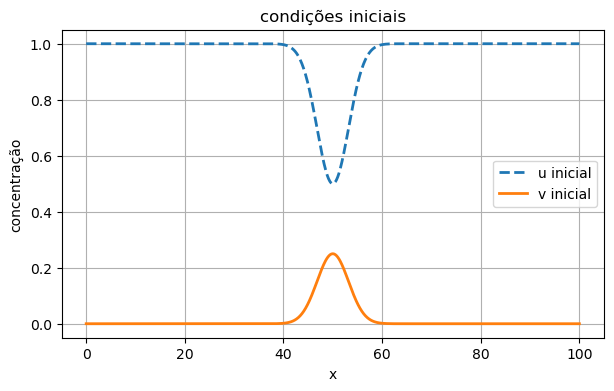

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_values, u_history[0], "--", lw=2, label="u inicial")
ax.plot(x_values, v_history[0], lw=2, label="v inicial")
ax.set_xlabel("x")
ax.set_ylabel("concentração")
ax.set_title("condições iniciais")
ax.grid(True)
ax.legend()
plt.show()

## Evolução temporal

O laço a seguir resolve um sistema não linear em cada passo. Guardamos os
perfis em todos os instantes porque a visualização espaço-tempo é parte
importante da interpretação do modelo.

In [9]:
for step in range(1, num_steps + 1):
    problem.solve()
    w0.x.array[:] = w.x.array
    w0.x.scatter_forward()

    u_plot.interpolate(u_expr)
    v_plot.interpolate(v_expr)
    u_history[step, :] = u_plot.x.array.real[order]
    v_history[step, :] = v_plot.x.array.real[order]

    if step % 500 == 0:
        print(f"passo {step:4d} / {num_steps}")

print(f"u em [{u_history[-1].min():.6e}, {u_history[-1].max():.6e}]")
print(f"v em [{v_history[-1].min():.6e}, {v_history[-1].max():.6e}]")

passo  500 / 4000
passo 1000 / 4000
passo 1500 / 4000
passo 2000 / 4000
passo 2500 / 4000
passo 3000 / 4000
passo 3500 / 4000
passo 4000 / 4000
u em [1.875516e-03, 1.000000e+00]
v em [0.000000e+00, 4.836624e+00]


## Perfis espaciais em um instante selecionado

Para ficar alinhado com o material original, visualizamos as concentrações no
tempo final. Se desejar, basta alterar `selected_time`.

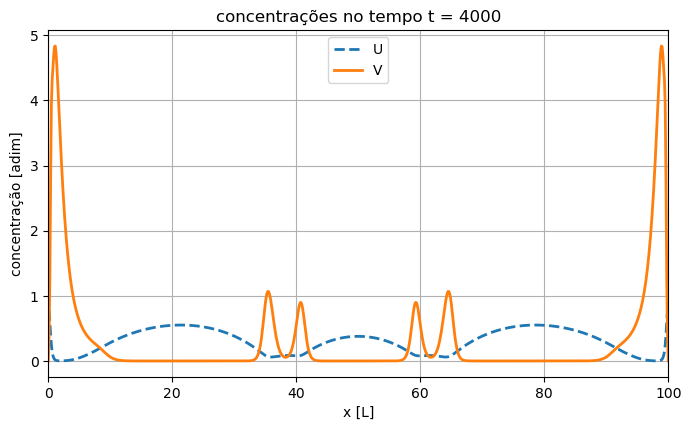

In [10]:
selected_time = 4000.0
selected_index = int(round(selected_time / dt_value))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_values, u_history[selected_index], "--", lw=2, label="U")
ax.plot(x_values, v_history[selected_index], lw=2, label="V")
ax.set_xlabel("x [L]")
ax.set_ylabel("concentração [adim]")
ax.set_xlim(x_values.min(), x_values.max())
ax.set_title(f"concentrações no tempo t = {times[selected_index]:.0f}")
ax.grid(True)
ax.legend()
plt.show()

## Evolução espaço-tempo da componente $v$

Este é o gráfico clássico do notebook original. Cada linha da imagem
representa um instante de tempo, e o eixo horizontal representa a posição no
intervalo.

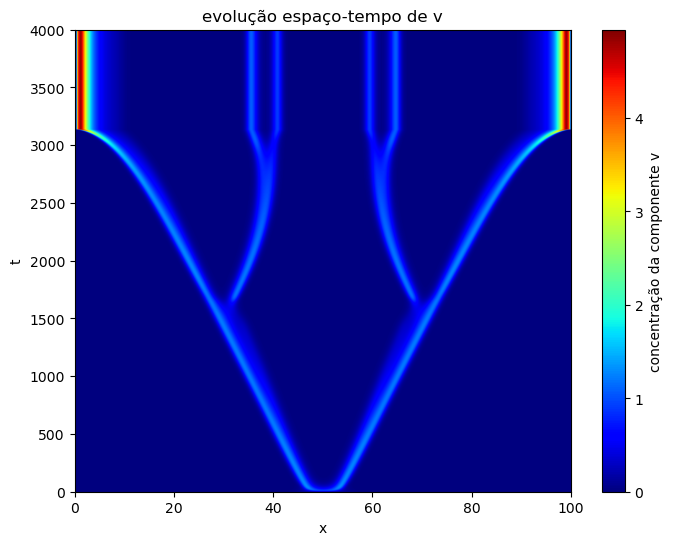

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    v_history,
    origin="lower",
    aspect="auto",
    extent=[x_values.min(), x_values.max(), times[0], times[-1]],
    cmap="jet",
    vmin=float(v_history.min()),
    vmax=float(v_history.max()),
)
fig.colorbar(image, ax=ax, label="concentração da componente v")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("evolução espaço-tempo de v")
plt.show()

## Comentário final

Este notebook faz algumas escolhas fortes:

- reduzimos o problema para 1D;
- adotamos um conjunto específico de parâmetros;
- usamos um solver de Newton direto com fatoração LU.

Essas escolhas são excelentes para fins didáticos e para reproduzir o exemplo
de referência, mas não devem ser tomadas automaticamente como a melhor opção
para problemas maiores ou para estudos quantitativos mais extensos.